# 06. Evaluate Forecast Skill

Out-of-sample verification for leads 1–12 months using the manuscript configuration.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eams_seof.config import load_config, resolve_path

CONFIG_PATH = REPO_ROOT / "configs" / "manuscript.yml"
cfg = load_config(CONFIG_PATH, repo_root=REPO_ROOT)


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

from eams_seof.forecast import fixed_base_anomaly
from eams_seof.preprocessing import detrend_anomaly
from eams_seof.time import datetime_to_decimal_year
from eams_seof.verification import (
    evaluate_skill,
    evaluate_configs,
    load_masks,
    plot_regional_skill,
    evaluate_persistence_benchmark,
    plot_centered_acc_sensitivity,
    build_anomaly_persistence_forecast,
    build_acc_refinement,
    plot_acc_refinement,
)

forecast_path = resolve_path(REPO_ROOT, cfg["paths"]["forecast_output"])
mask_path = resolve_path(REPO_ROOT, cfg["paths"]["region_masks"])
skill_path = resolve_path(REPO_ROOT, cfg["paths"]["skill_output"])
sst_path = resolve_path(REPO_ROOT, cfg["paths"]["oisst_smoothed"])
mode1_forecast_path = resolve_path(REPO_ROOT, cfg["paths"]["mode1_forecast_output"])
acc_refinement_data_path = resolve_path(REPO_ROOT, cfg["paths"]["acc_refinement_output"])

regional_skill_path = resolve_path(REPO_ROOT, cfg["figs"]["regional_skill"])
acc_refinement_path = resolve_path(REPO_ROOT, cfg["figs"]["acc_refinement"])

main_fig6_path = REPO_ROOT / "outputs/png/fig6_acc_msss_pss.png"
persistence_skill_path = REPO_ROOT / "outputs/verification/trend_adjusted_persistence_benchmark.nc"
centered_acc_path = REPO_ROOT / "outputs/png/centered_acc_sensitivity.png"
climatology_sensitivity_path = REPO_ROOT / "outputs/verification/climatology_base_sensitivity.nc"
climatology_sensitivity_table_path = REPO_ROOT / "outputs/verification/climatology_base_sensitivity_summary.csv"
rolling_sensitivity_table_path = REPO_ROOT / "outputs/verification/rolling_correction_sensitivity_leads1_12.csv"

forecast_ds = xr.open_dataset(forecast_path)
mask_ds = xr.open_dataset(mask_path)


## Forecast verification


In [3]:
observed = forecast_ds["sst_observed_fixed_base_anomaly"]
forecasts = {
    "uncorrected": forecast_ds["sst_forecast_fixed_base_anomaly"],
    "corrected": forecast_ds["sst_forecast_fixed_base_anomaly_corrected"],
}

masks = load_masks(mask_ds, observed.isel(time=0))
assert np.array_equal(
    masks["EAMS"].values,
    (masks["YS"] | masks["ECS"] | masks["EJS"]).values,
)

v = cfg["verification"]
primary_configuration = v["primary_configuration"]
sensitivity_configuration = v["sensitivity_configuration"]

if primary_configuration != "corrected":
    raise ValueError(
        f"Expected primary_configuration='corrected', got {primary_configuration!r}"
    )
if sensitivity_configuration != "uncorrected":
    raise ValueError(
        f"Expected sensitivity_configuration='uncorrected', got {sensitivity_configuration!r}"
    )
if not np.isclose(float(v["fdr_q"]), 0.10):
    raise ValueError(
        f"Expected manuscript FDR q=0.10, got {float(v['fdr_q'])}"
    )

skill = evaluate_configs(
    forecasts=forecasts,
    observed=observed,
    masks=masks,
    verification_period=tuple(cfg["periods"]["verification"]),
    min_samples=int(v["minimum_samples"]),
    n_boot=int(v["bootstrap_samples"]),
    min_boot_valid=int(v["minimum_bootstrap_valid"]),
    ci_level=float(v["ci_level"]),
    fdr_q=float(v["fdr_q"]),
    target_month_fdr_scope=v["target_month_fdr_scope"],
    seasonal_fdr_scope=v["seasonal_fdr_scope"],
    seed=int(v["random_seed"]),
)

skill.attrs.update({
    "forecast_source": str(forecast_path),
    "fixed_anomaly_base": str(cfg["periods"]["fixed_anomaly_base"]),
    "primary_configuration": primary_configuration,
    "eams_definition": "YS | ECS | EJS",
    "interpreted_leads": "1-12 months",
})

skill_path.parent.mkdir(parents=True, exist_ok=True)
skill.to_netcdf(skill_path)

eams = skill.sel(configuration=primary_configuration, region="EAMS")
print("Primary configuration:", primary_configuration)
print("FDR q:", float(v["fdr_q"]))
for metric in ["ACC", "MSSS"]:
    sig = eams[f"TARGET_SIG_{metric}"].sel(lead=slice(1, None))
    print(f"{metric}: {int(sig.sum())} / {sig.size} significant cells")


Primary configuration: corrected
FDR q: 0.1
ACC: 144 / 144 significant cells
MSSS: 111 / 144 significant cells


## Rolling mean-state correction sensitivity


In [4]:
rows = []

for metric in ["ACC", "CENTERED_ACC", "MSSS", "RMSE"]:
    values = {}
    for configuration in ["uncorrected", "corrected"]:
        da = skill[f"TARGET_{metric}"].sel(
            configuration=configuration,
            region="EAMS",
            lead=slice(1, None),
        )
        values[configuration] = float(da.mean(skipna=True))
    rows.append({
        "metric": metric,
        "uncorrected": values["uncorrected"],
        "corrected": values["corrected"],
        "corrected_minus_uncorrected": values["corrected"] - values["uncorrected"],
    })

bias_values = {}
for configuration in ["uncorrected", "corrected"]:
    bias = skill["TARGET_BIAS"].sel(
        configuration=configuration,
        region="EAMS",
        lead=slice(1, None),
    )
    bias_values[configuration] = float(np.abs(bias).mean(skipna=True))

rows.append({
    "metric": "|BIAS|",
    "uncorrected": bias_values["uncorrected"],
    "corrected": bias_values["corrected"],
    "corrected_minus_uncorrected": bias_values["corrected"] - bias_values["uncorrected"],
})

rolling_sensitivity = pd.DataFrame(rows)
rolling_sensitivity_table_path.parent.mkdir(parents=True, exist_ok=True)
rolling_sensitivity.to_csv(rolling_sensitivity_table_path, index=False)
print("Saved:", rolling_sensitivity_table_path)


Saved: /Users/jhyun/Library/CloudStorage/OneDrive-개인/jhyun91/GloSea6-SSTA-EAMS-SEOF_v1/outputs/verification/rolling_correction_sensitivity_leads1_12.csv


## Trend-adjusted persistence benchmark

The initialization-time detrended anomaly is persisted to the target month, then the training climatology and fitted target-time trend are restored before conversion to the fixed anomaly base.


In [5]:
sst = xr.open_dataset(sst_path)["sst"].sel(
    lat=slice(*cfg["domain"]["latitude"]),
    lon=slice(*cfg["domain"]["longitude"]),
)
sea_mask = np.isfinite(sst).any("time")
training_period = tuple(cfg["periods"]["training"])
fixed_base_period = tuple(cfg["periods"]["fixed_anomaly_base"])

(
    detrended_sst,
    training_climatology,
    trend_coefficients,
    reference_decimal_year,
) = detrend_anomaly(
    sst,
    training_period=training_period,
    sea_mask=sea_mask,
)

persistence_detrended = build_anomaly_persistence_forecast(
    observed_anomaly=detrended_sst,
    forecast_template=forecasts[primary_configuration],
)

target_index = pd.DatetimeIndex(persistence_detrended.target_time.values)
target_month = xr.DataArray(
    target_index.month.astype(np.int16),
    coords={"target_time": persistence_detrended.target_time},
    dims=("target_time",),
)
target_decimal_year = xr.DataArray(
    datetime_to_decimal_year(target_index).astype(np.float32),
    coords={"target_time": persistence_detrended.target_time},
    dims=("target_time",),
)

seasonal_target = training_climatology.sel(month=target_month).reset_coords(drop=True)
trend_target = (
    trend_coefficients.sel(coef="intercept")
    + trend_coefficients.sel(coef="slope")
    * (target_decimal_year - float(reference_decimal_year))
).reset_coords(drop=True)

persistence_absolute = (
    persistence_detrended + seasonal_target + trend_target
).astype(np.float32)
persistence_absolute.name = "sst_trend_adjusted_persistence_absolute"

persistence_forecast, persistence_observed = fixed_base_anomaly(
    absolute_forecast_target=persistence_absolute,
    observed_sst=sst,
    fixed_base_period=fixed_base_period,
    sea_mask=sea_mask,
)

obs_ref = observed.sel(time=slice(*cfg["periods"]["verification"]))
obs_new = persistence_observed.sel(time=slice(*cfg["periods"]["verification"]))
obs_ref, obs_new = xr.align(obs_ref, obs_new, join="inner")
assert float(np.nanmax(np.abs((obs_ref - obs_new).values))) < 1e-6


In [6]:
persistence_skill = evaluate_persistence_benchmark(
    model_forecast=forecasts[primary_configuration],
    persistence_forecast=persistence_forecast,
    observed=observed,
    masks=masks,
    verification_period=tuple(cfg["periods"]["verification"]),
    min_samples=int(v["minimum_samples"]),
    n_boot=int(v["bootstrap_samples"]),
    min_boot_valid=int(v["minimum_bootstrap_valid"]),
    ci_level=float(v["ci_level"]),
    fdr_q=float(v["fdr_q"]),
    target_month_fdr_scope=v["target_month_fdr_scope"],
    seasonal_fdr_scope=v["seasonal_fdr_scope"],
    seed=int(v["random_seed"]) + 400000,
)

persistence_skill.attrs.update({
    "model_configuration": primary_configuration,
    "benchmark": "trend-adjusted anomaly persistence",
    "training_period": str(training_period),
    "fixed_anomaly_base": str(fixed_base_period),
    "interpreted_leads": "1-12 months",
})

persistence_skill_path.parent.mkdir(parents=True, exist_ok=True)
persistence_skill.to_netcdf(persistence_skill_path)

eams_pss = persistence_skill["TARGET_PSS"].sel(
    region="EAMS", lead=slice(1, None)
)
eams_pss_sig = persistence_skill["TARGET_SIG_PSS"].sel(
    region="EAMS", lead=slice(1, None)
)

print("EAMS mean PSS:", float(eams_pss.mean(skipna=True)))
print(
    "FDR-supported positive PSS cells:",
    int(eams_pss_sig.sum()), "/", eams_pss_sig.size,
)


EAMS mean PSS: 0.042435236275196075
FDR-supported positive PSS cells: 7 / 144


## Main Fig. 6


In [7]:
def plot_main_fig6(skill_ds, persistence_ds, configuration, region="EAMS", savepath=None):
    import cmaps
    import matplotlib as mpl
    import matplotlib.ticker as mticker
    import proplot as pplt

    ds = skill_ds.sel(configuration=configuration)
    ds = ds.sel(lead=ds.lead > 0)
    pds = persistence_ds.sel(lead=persistence_ds.lead > 0)

    leads = ds.lead.values.astype(int)
    months = ds.month.values.astype(int)
    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
                   "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

    acc = ds["TARGET_ACC"].sel(region=region).transpose("lead", "month").values
    msss = ds["TARGET_MSSS"].sel(region=region).transpose("lead", "month").values
    pss = pds["TARGET_PSS"].sel(region=region).transpose("lead", "month").values

    sig_acc = ds["TARGET_SIG_ACC"].sel(region=region).transpose("lead", "month").values.astype(bool)
    sig_msss = ds["TARGET_SIG_MSSS"].sel(region=region).transpose("lead", "month").values.astype(bool)
    sig_pss = pds["TARGET_SIG_PSS"].sel(region=region).transpose("lead", "month").values.astype(bool)

    base_cmap = cmaps.sunshine_diff_12lev
    levels = [-0.2, 0.2, 0.4, 0.6, 0.8]
    colors = base_cmap(np.linspace(0, 1, 11))
    seq_cmap = mpl.colors.ListedColormap(
        [[1, 1, 1, 1], colors[6], colors[7], colors[8]]
    )
    seq_cmap.set_under(colors[0])
    seq_cmap.set_over(colors[10])
    seq_norm = mpl.colors.BoundaryNorm(levels, seq_cmap.N)

    pss_cmap = mpl.cm.get_cmap("RdBu_r")
    finite_pss = np.abs(pss[np.isfinite(pss)])
    pss_lim = max(0.10, float(np.nanpercentile(finite_pss, 95))) if finite_pss.size else 0.10
    pss_norm = mpl.colors.TwoSlopeNorm(vmin=-pss_lim, vcenter=0.0, vmax=pss_lim)

    x_edges = np.arange(0.5, 13.5, 1.0)
    y_edges = np.arange(leads.min() - 0.5, leads.max() + 1.5, 1.0)

    fig, axs = pplt.subplots(
        nrows=1, ncols=3, figwidth="19cm", share=False, wspace=3.0
    )
    axs.format(grid=False, ec="black", lw=1.0)

    panels = [
        (acc, sig_acc, seq_cmap, seq_norm, r"$\mathbf{(a)}$ ACC", "ACC"),
        (msss, sig_msss, seq_cmap, seq_norm, r"$\mathbf{(b)}$ MSSS", "MSSS"),
        (pss, sig_pss, pss_cmap, pss_norm, r"$\mathbf{(c)}$ Persistence skill score", "PSS"),
    ]

    meshes = []
    for ax, (values, sig, cmap, norm, title, _) in zip(axs, panels):
        mesh = ax.pcolormesh(
            x_edges, y_edges, np.ma.masked_invalid(values),
            cmap=cmap, norm=norm, shading="flat"
        )
        ii, jj = np.where(sig & np.isfinite(values))
        ax.scatter(months[jj], leads[ii], s=7, c="k", zorder=5)
        ax.format(
            title=title,
            titleloc="l",
            xlim=(0.5, 12.5),
            ylim=(leads.min() - 0.5, leads.max() + 0.5),
            xticks=months,
            xticklabels=month_names,
            xrotation=45,
            yticks=leads,
            xlabel="Target Month",
            ylabel="Lead Time (months)",
            grid=False,
        )
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.yaxis.set_minor_locator(mticker.NullLocator())
        meshes.append(mesh)

    for i, (mesh, (_, _, _, _, _, label)) in enumerate(zip(meshes, panels)):
        cbar = fig.colorbar(
            mesh,
            col=(i + 1, i + 1),
            loc="b",
            label=label,
            length=0.80,
            width=0.10,
        )
        cbar.ax.xaxis.set_minor_locator(mticker.NullLocator())
        cbar.ax.yaxis.set_minor_locator(mticker.NullLocator())

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.save(savepath, dpi=600)

    return fig, axs


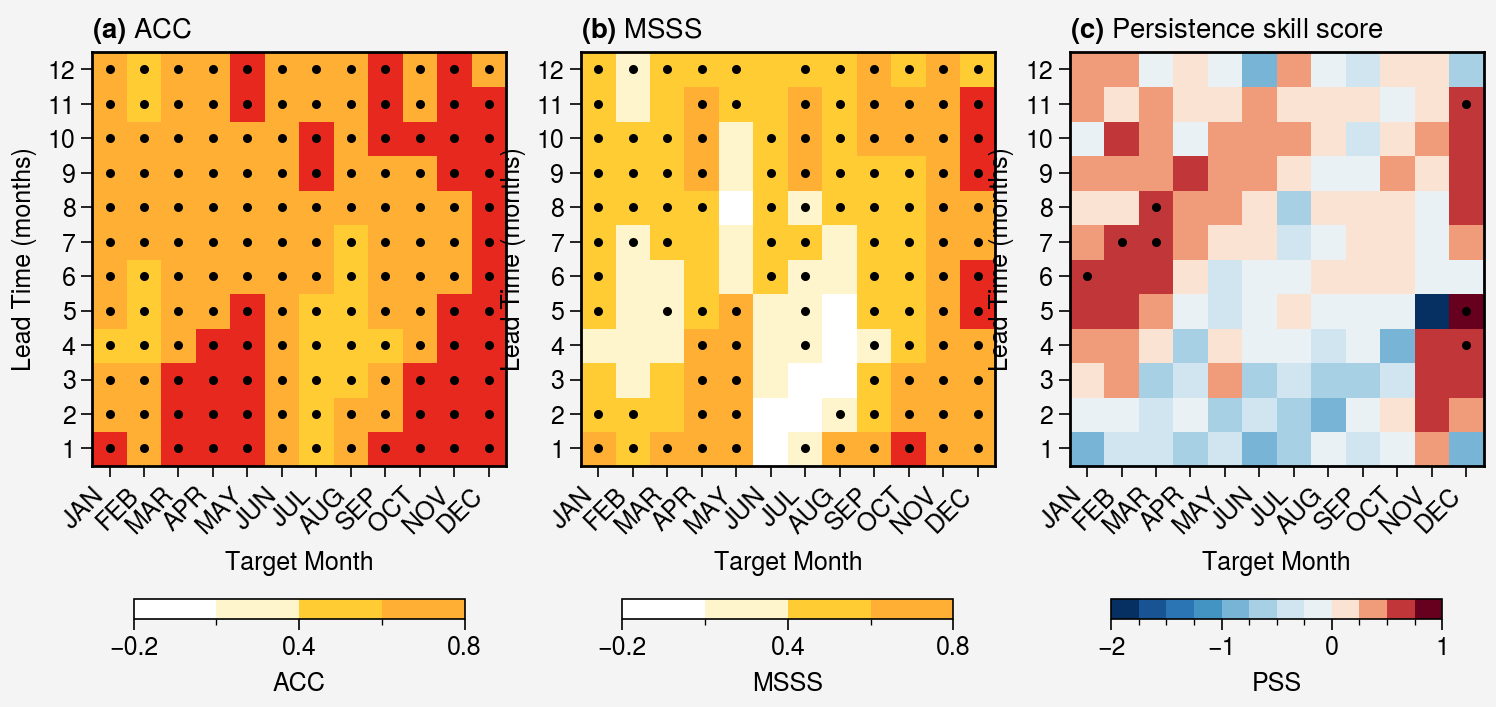

In [8]:
fig6, axs6 = plot_main_fig6(
    skill,
    persistence_skill,
    configuration=primary_configuration,
    region="EAMS",
    savepath=main_fig6_path,
)


## Regional seasonal skill


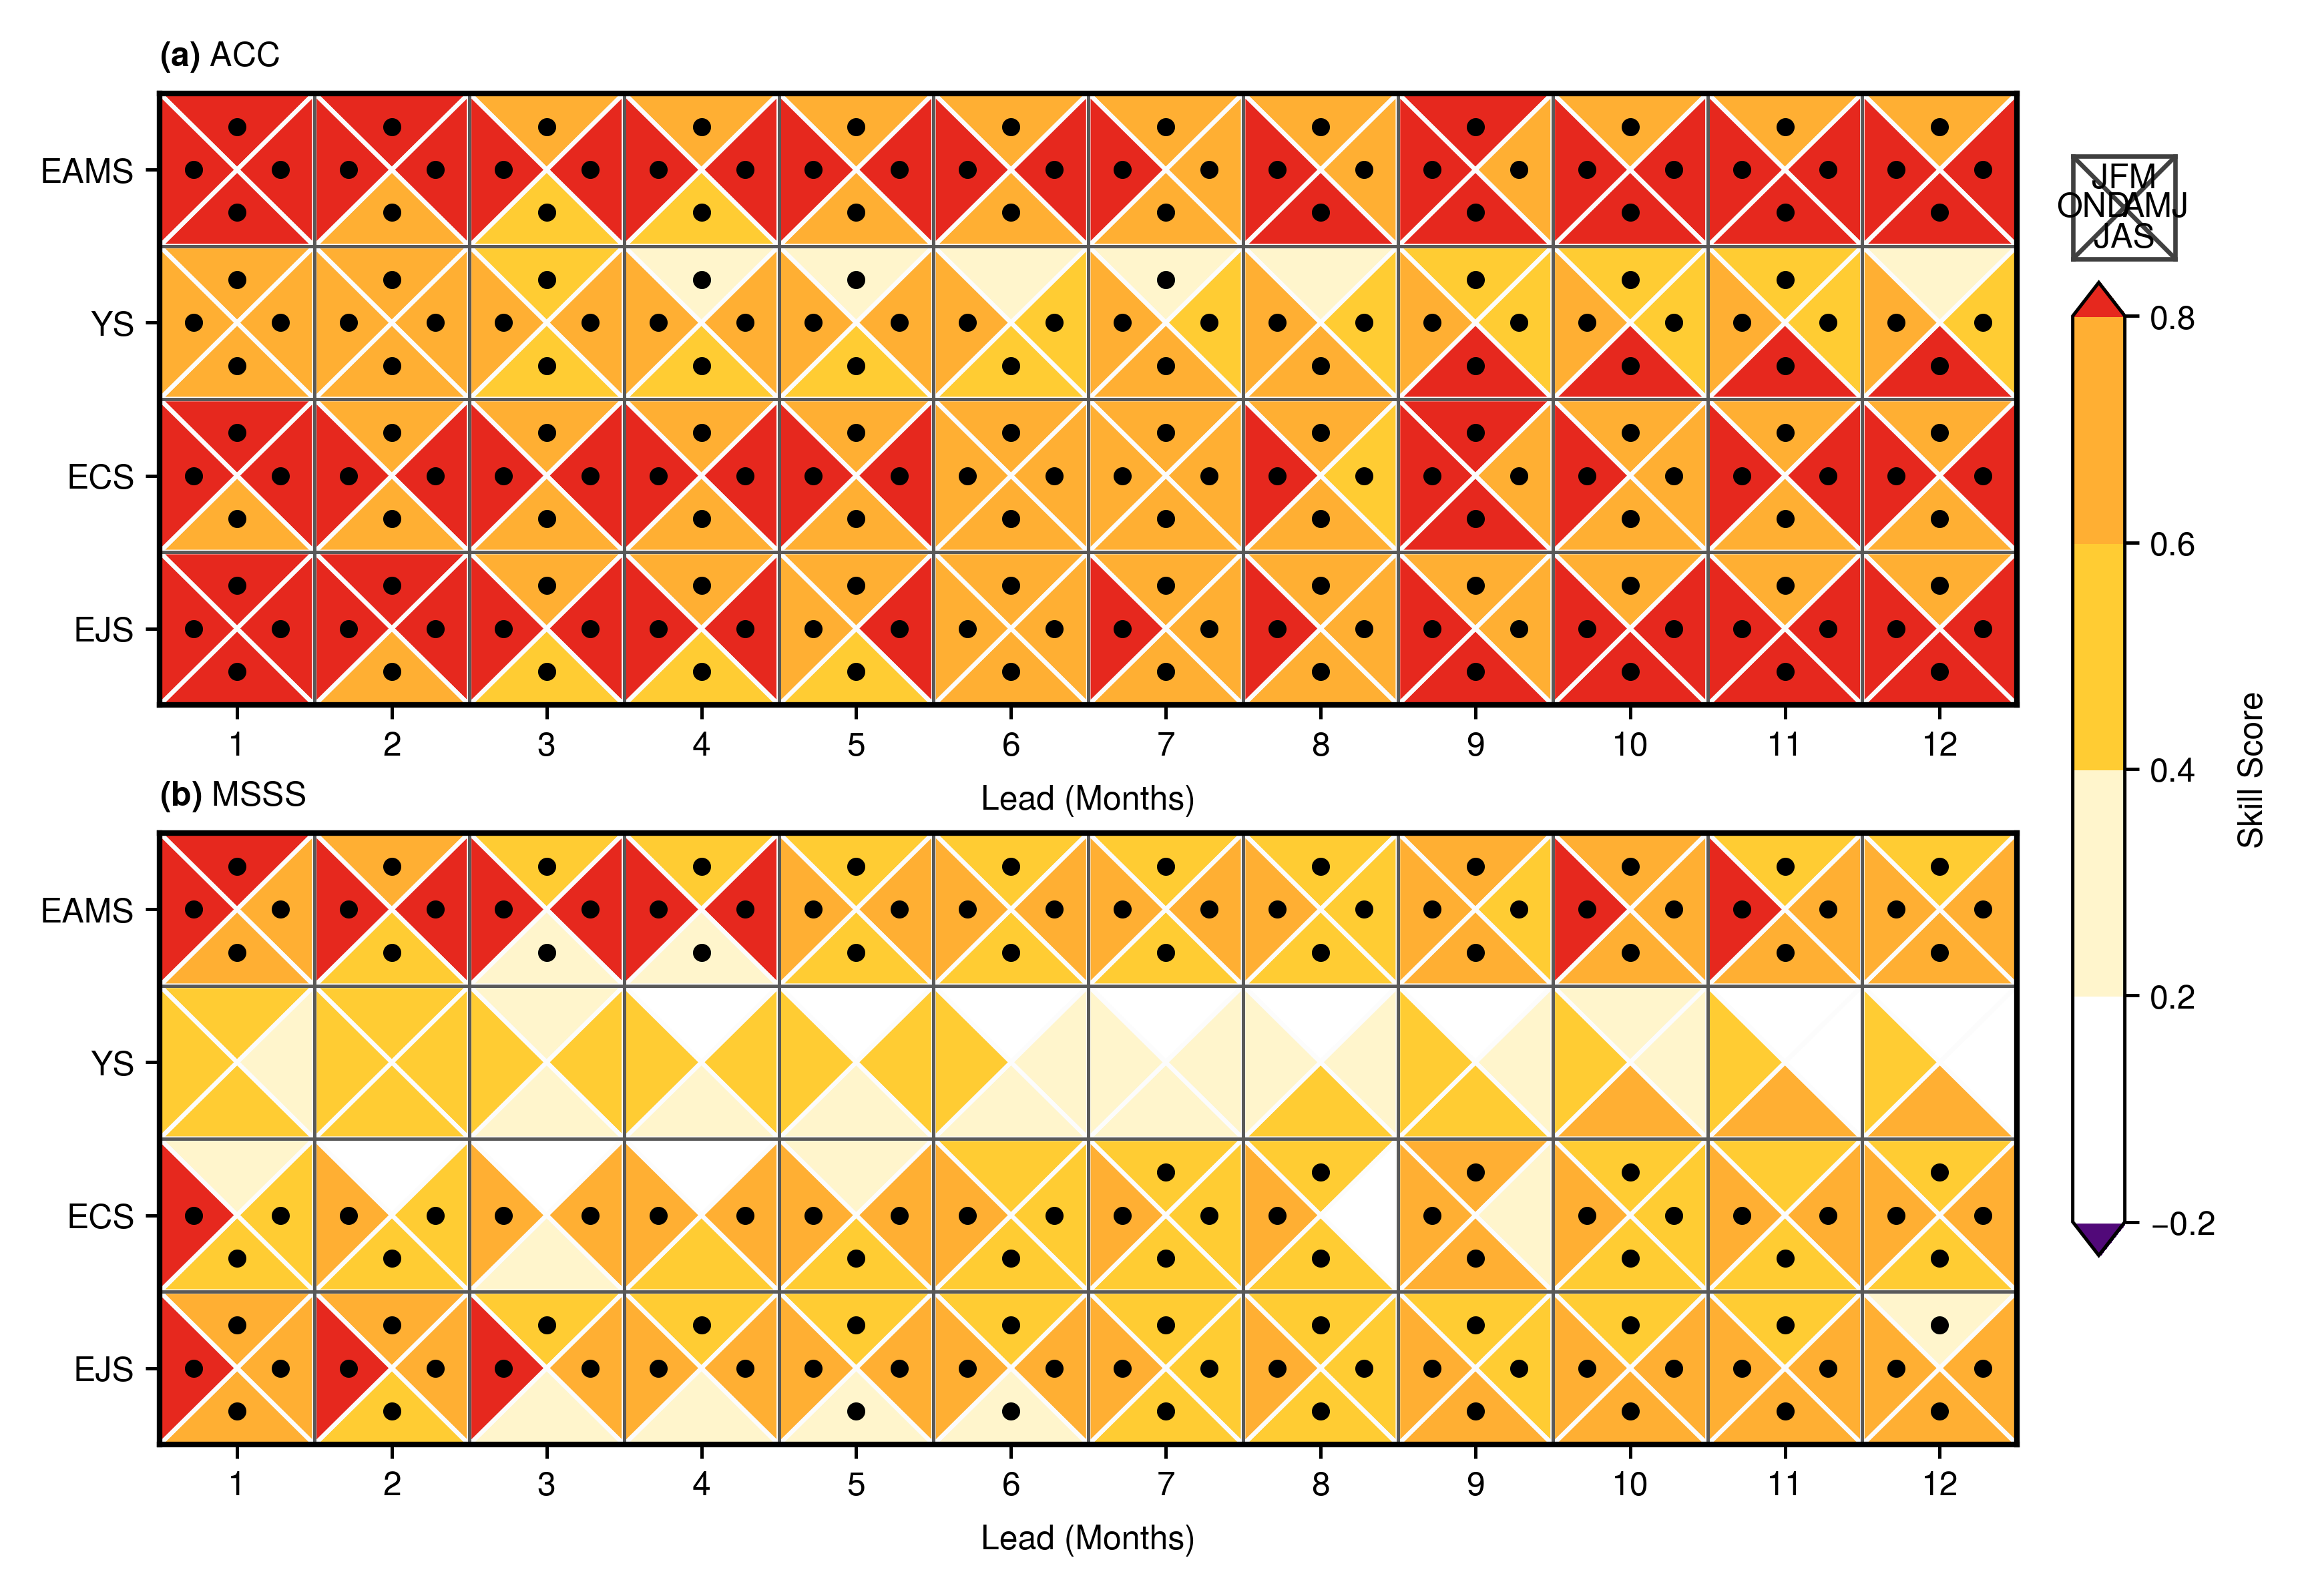

In [9]:
fig_reg, axs_reg = plot_regional_skill(
    skill,
    configuration=primary_configuration,
    regions=("EAMS", "YS", "ECS", "EJS"),
    savepath=regional_skill_path,
    exclude_lead0=True,
)


## Supplementary sensitivity analyses


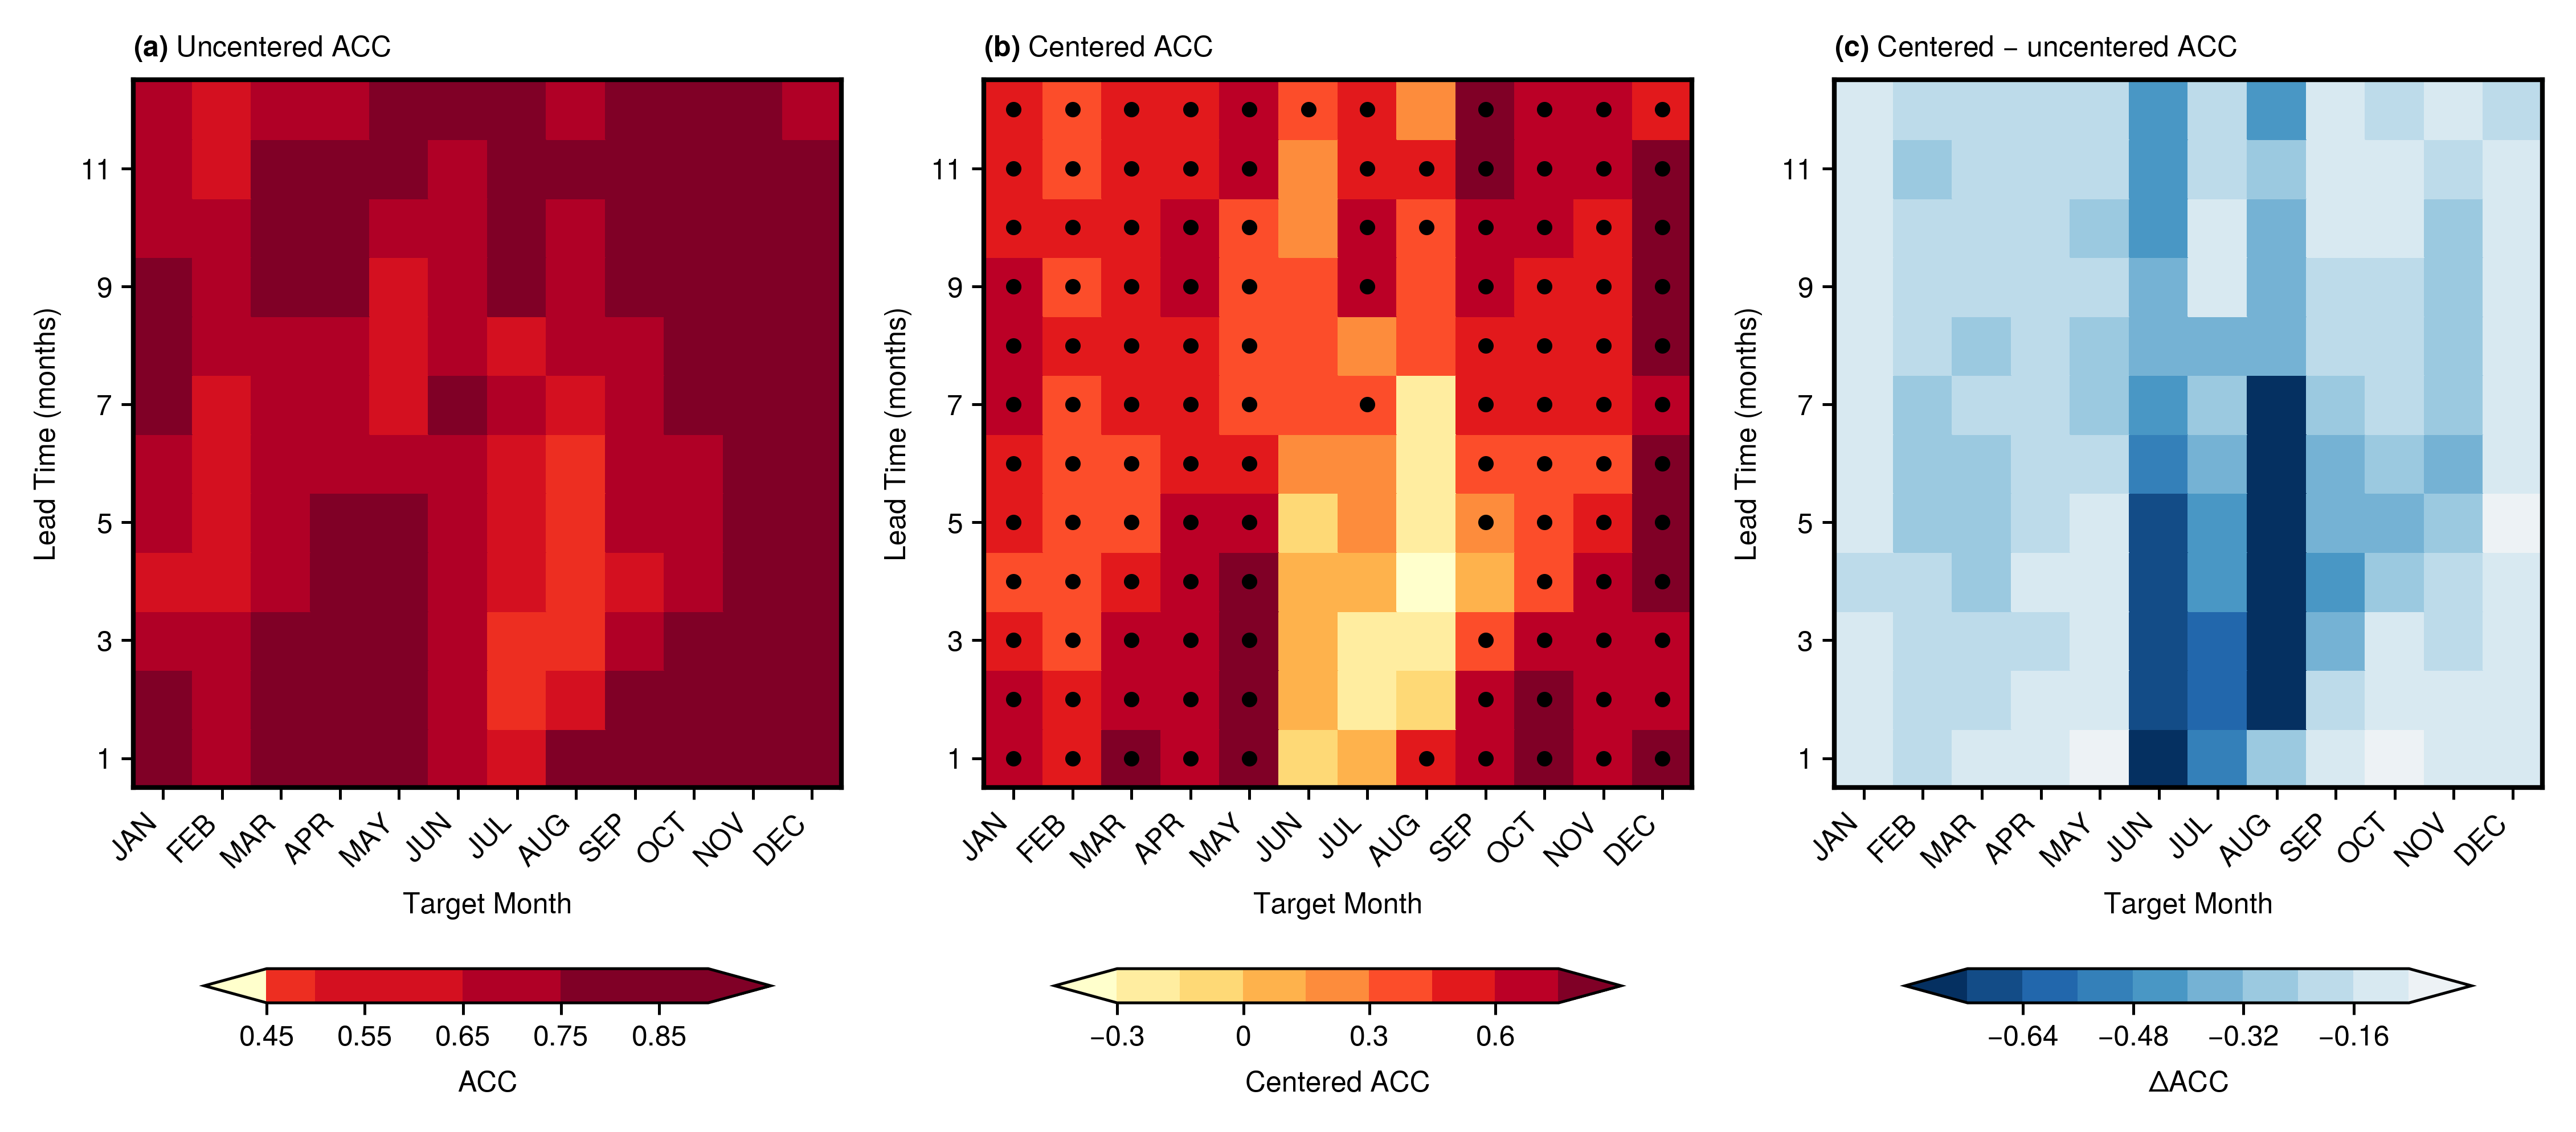

In [10]:
fig_centered, axs_centered = plot_centered_acc_sensitivity(
    skill,
    configuration=primary_configuration,
    region="EAMS",
    savepath=centered_acc_path,
    exclude_lead0=True,
)


In [11]:
training_base_period = tuple(cfg["periods"]["training"])

if primary_configuration == "corrected":
    absolute_primary = forecast_ds["sst_forecast_absolute_corrected"]
elif primary_configuration == "uncorrected":
    absolute_primary = forecast_ds["sst_forecast_absolute"]
else:
    raise ValueError(f"Unknown primary configuration: {primary_configuration!r}")

training_base_forecast, training_base_observed = fixed_base_anomaly(
    absolute_forecast_target=absolute_primary,
    observed_sst=sst,
    fixed_base_period=training_base_period,
    sea_mask=sea_mask,
)

training_base_skill = evaluate_skill(
    forecast=training_base_forecast,
    observed=training_base_observed,
    masks=masks,
    verification_period=tuple(cfg["periods"]["verification"]),
    min_samples=int(v["minimum_samples"]),
    n_boot=int(v["bootstrap_samples"]),
    min_boot_valid=int(v["minimum_bootstrap_valid"]),
    ci_level=float(v["ci_level"]),
    fdr_q=float(v["fdr_q"]),
    target_month_fdr_scope=v["target_month_fdr_scope"],
    seasonal_fdr_scope=v["seasonal_fdr_scope"],
    seed=int(v["random_seed"]) + 600000,
)

reference_label = "1993–2016"
training_label = "1993–2012"
reference_skill = skill.sel(configuration=primary_configuration, drop=True)

base_sensitivity = xr.concat(
    [
        reference_skill.expand_dims(anomaly_base=[reference_label]),
        training_base_skill.expand_dims(anomaly_base=[training_label]),
    ],
    dim="anomaly_base",
    combine_attrs="drop_conflicts",
)

climatology_sensitivity_path.parent.mkdir(parents=True, exist_ok=True)
base_sensitivity.to_netcdf(climatology_sensitivity_path)

rows = []
for metric in ["ACC", "CENTERED_ACC", "MSSS"]:
    ref = base_sensitivity[f"TARGET_{metric}"].sel(
        anomaly_base=reference_label,
        region="EAMS",
        lead=slice(1, None),
    )
    alt = base_sensitivity[f"TARGET_{metric}"].sel(
        anomaly_base=training_label,
        region="EAMS",
        lead=slice(1, None),
    )
    rows.append({
        "metric": metric,
        "reference_base": reference_label,
        "alternate_base": training_label,
        "mean_reference": float(ref.mean(skipna=True)),
        "mean_alternate": float(alt.mean(skipna=True)),
        "mean_difference_alternate_minus_reference": float((alt - ref).mean(skipna=True)),
    })

pd.DataFrame(rows).to_csv(climatology_sensitivity_table_path, index=False)


## Forecast-dimensionality sensitivity


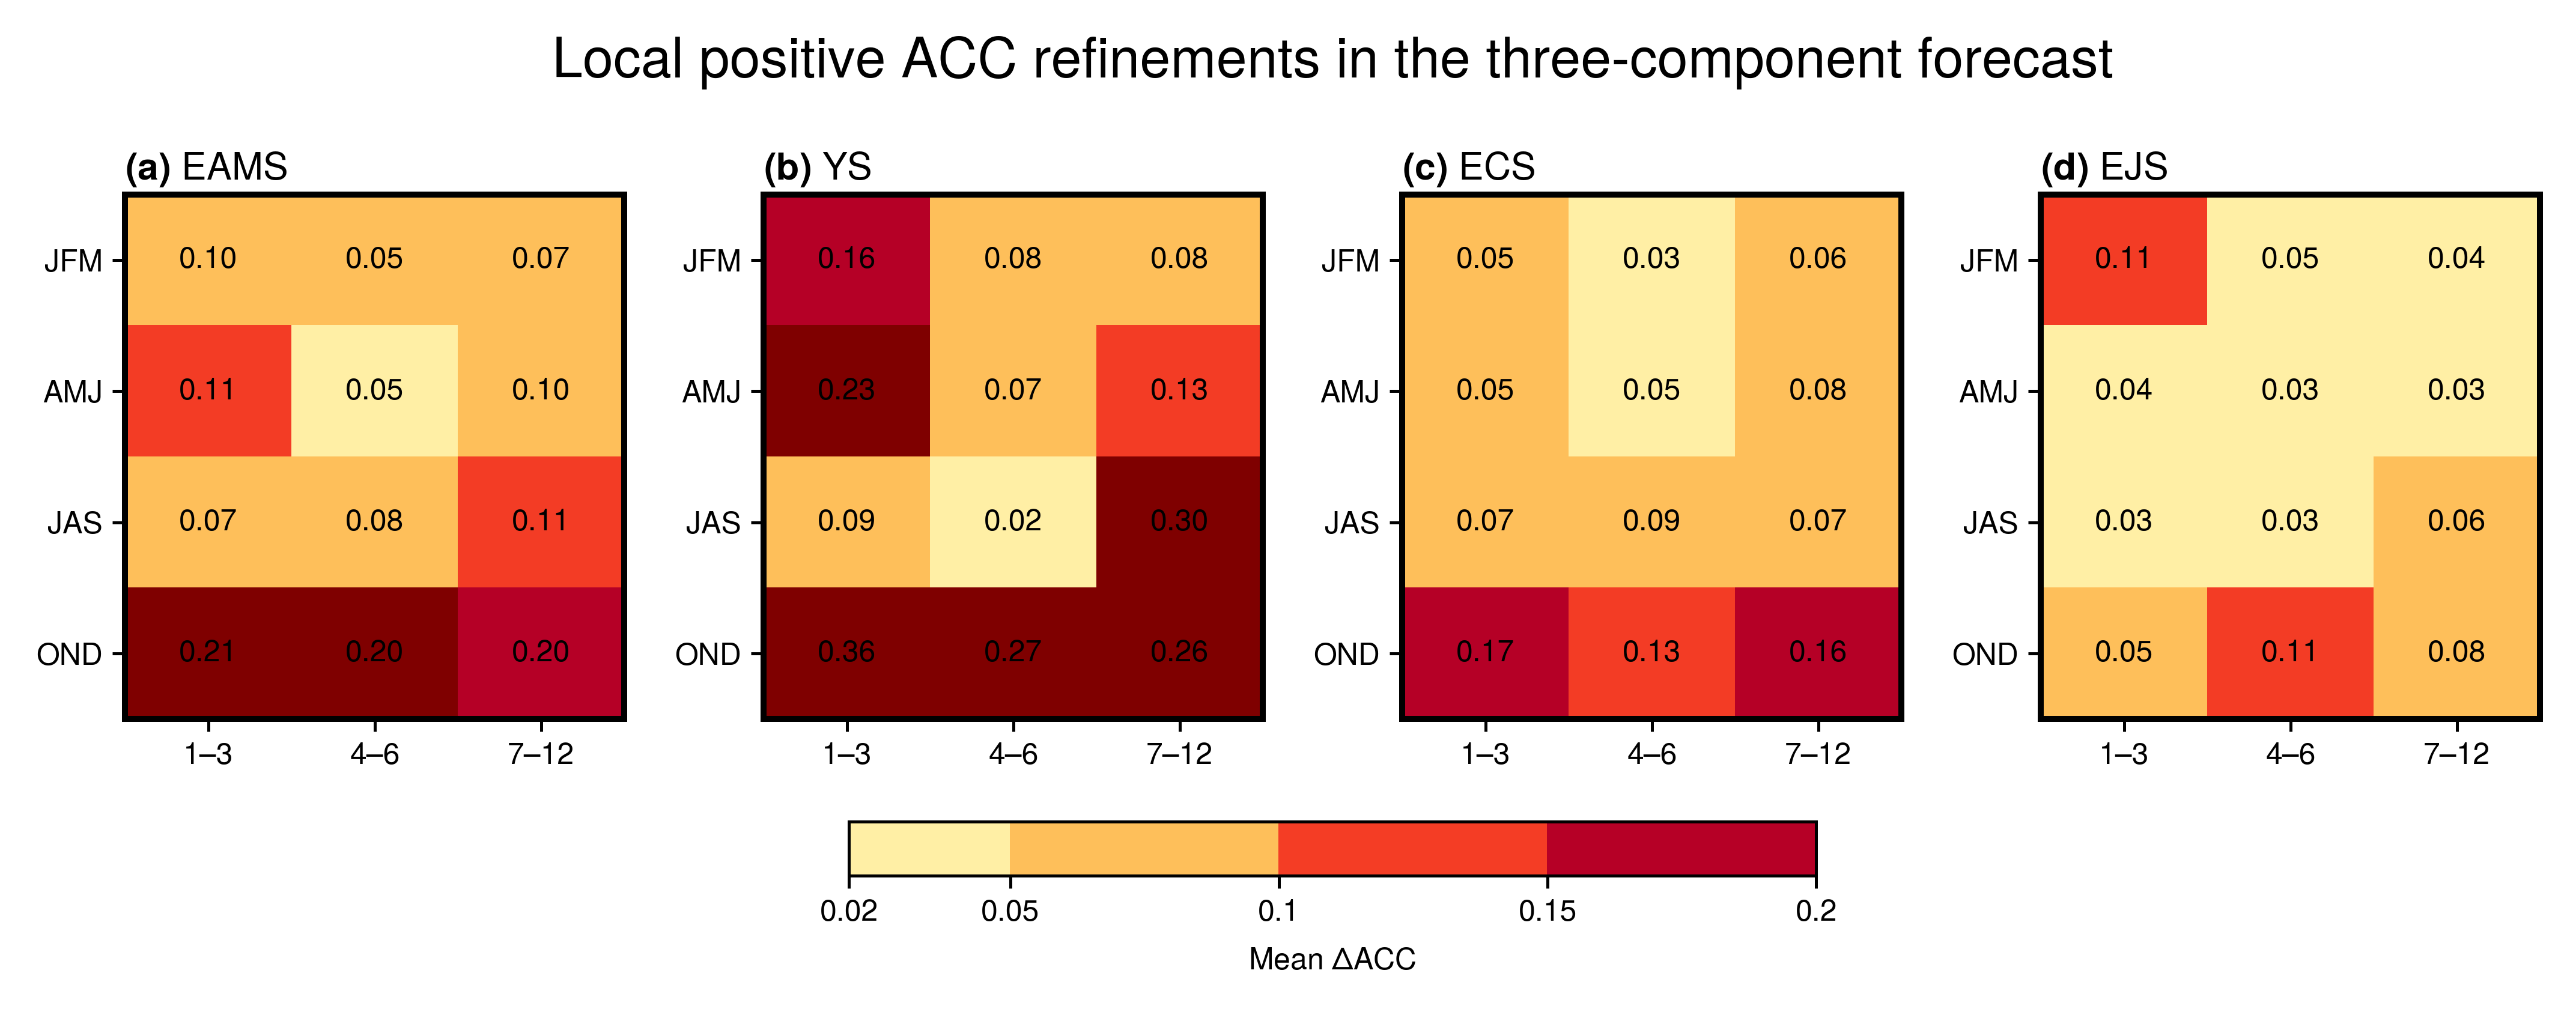

In [12]:
if not mode1_forecast_path.exists():
    raise FileNotFoundError(f"Run notebook 05 first: {mode1_forecast_path}")

refinement = build_acc_refinement(
    mode1_path=mode1_forecast_path,
    full_model_path=forecast_path,
    region_masks=masks,
    summary_path=acc_refinement_data_path,
    verification_period=tuple(cfg["periods"]["verification"]),
    threshold_quantile=float(v["acc_refinement_quantile"]),
)

fig_ref, axs_ref = plot_acc_refinement(
    refinement,
    savepath=acc_refinement_path,
)
